In [ ]:
# [Dataset: IRIS dataset available in sklearn.datasets. Separate the
# dataset into features (sepal length, sepal width, petal length, petal
# width) and target labels (setosa, versicolor, virginica).]
# 1. Implement DBSCAN clustering algorithm.
# ● Try the following [ε, MinPts] combinations: (0.3, 5), (0.5, 5),
# (0.7, 5).
# ● Report the number of clusters formed and number of noise
# points.
# ● Plot clusters using any 2 features.
# ● Evaluate using Adjusted Rand Index (ARI).
# 2. Implement Density Peak Clustering (DPC) and identify cluster centers
# using the decision graph.
# ● Compute local density (ρ) using cutoff distance (dc).
# ● Compute δ (distance to nearest higher-density point).
# ● Plot decision graph (ρ vs δ).
# ● Assign each point to the cluster of its nearest higher-density
# neighbor. Plot the final clusters.
# ● Evaluate using ARI.

# [Adjusted Rand Index: ARI is a metric used to evaluate clustering algorithms by
# measuring the similarity between two cluster assignments (true labels and predicted
# clusters) ]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

X = StandardScaler().fit_transform(X)

n = len(X)

In [ ]:
def region_query(X, point, eps):
    dists = np.linalg.norm(X - point, axis=1)
    return np.where(dists <= eps)[0]


def dbscan(X, eps, minPts):

    n = len(X)

    labels = np.full(n, -1)  # -1 = noise
    visited = np.zeros(n, dtype=bool)

    cluster_id = 0

    for i in range(n):

        if visited[i]:
            continue

        visited[i] = True

        neighbors = region_query(X, X[i], eps)

        if len(neighbors) < minPts:
            labels[i] = -1
        else:

            labels[i] = cluster_id

            seed = list(neighbors)

            while seed:

                j = seed.pop()

                if not visited[j]:

                    visited[j] = True

                    neigh2 = region_query(X, X[j], eps)

                    if len(neigh2) >= minPts:
                        seed.extend(neigh2)

                if labels[j] == -1:
                    labels[j] = cluster_id

            cluster_id += 1

    return labels

In [ ]:
def plot_clusters(X, labels, title):

    plt.figure()

    plt.scatter(
        X[:,2],
        X[:,3],
        c=labels,
        cmap="rainbow"
    )

    plt.title(title)
    plt.xlabel("petal length")
    plt.ylabel("petal width")

    plt.show()

eps = 0.3 minPts = 5
clusters = 3
noise = 120
ARI = 0.08759538435941186



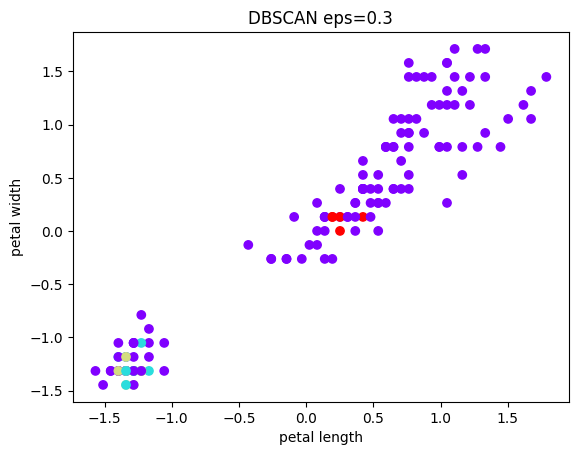

eps = 0.4 minPts = 5
clusters = 6
noise = 66
ARI = 0.36550715288152474



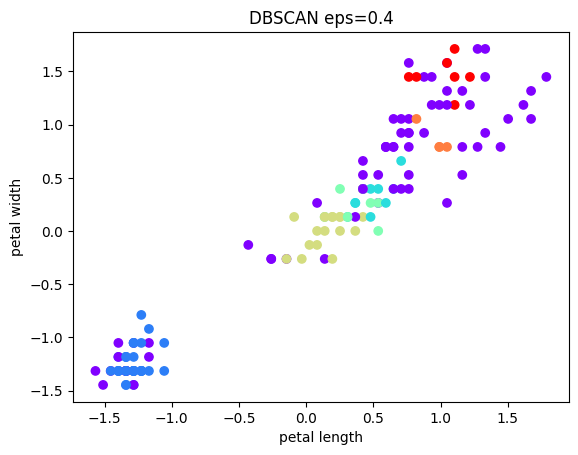

eps = 0.7 minPts = 5
clusters = 2
noise = 6
ARI = 0.5400773829118303



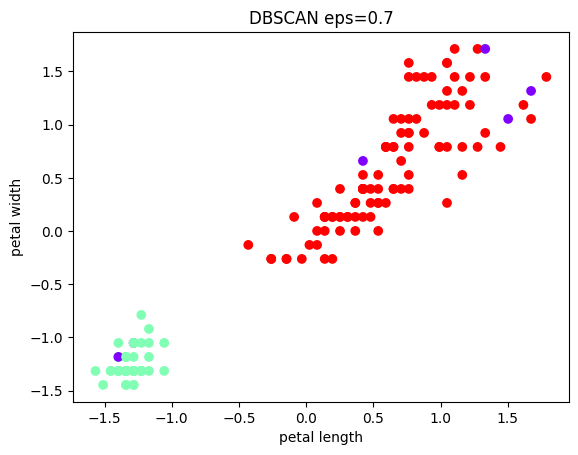

In [ ]:
params = [(0.3,5),(0.4,5),(0.7,5)]

for eps, minPts in params:

    labels = dbscan(X, eps, minPts)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    ari = adjusted_rand_score(y, labels)

    print("eps =", eps, "minPts =", minPts)
    print("clusters =", n_clusters)
    print("noise =", noise)
    print("ARI =", ari)
    print()

    plot_clusters(
        X,
        labels,
        f"DBSCAN eps={eps}"
    )

In [ ]:
D = cdist(X, X)

In [ ]:
dc = 0.5

rho = np.zeros(n)

for i in range(n):
    rho[i] = np.sum(D[i] < dc) - 1

In [ ]:
delta = np.zeros(n)

nearest = np.zeros(n, dtype=int)

sorted_idx = np.argsort(-rho)

delta[sorted_idx[0]] = np.max(D)
nearest[sorted_idx[0]] = -1

for i in range(1, n):

    idx = sorted_idx[i]

    higher = sorted_idx[:i]

    dist = D[idx][higher]

    j = np.argmin(dist)

    delta[idx] = dist[j]
    nearest[idx] = higher[j]

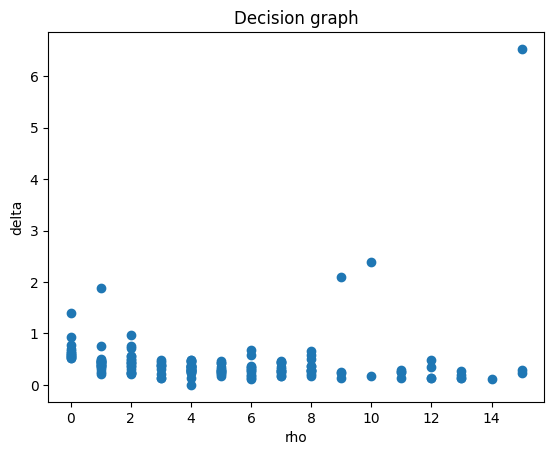

In [ ]:
plt.figure()

plt.scatter(rho, delta)

plt.xlabel("rho")
plt.ylabel("delta")

plt.title("Decision graph")

plt.show()

In [ ]:
centers = np.argsort(-(rho * delta))[:3]

print("centers =", centers)

centers = [  7  99 140]


In [ ]:
labels = -np.ones(n, dtype=int)

for i, c in enumerate(centers):
    labels[c] = i


for i in sorted_idx:

    if labels[i] == -1:
        labels[i] = labels[nearest[i]]

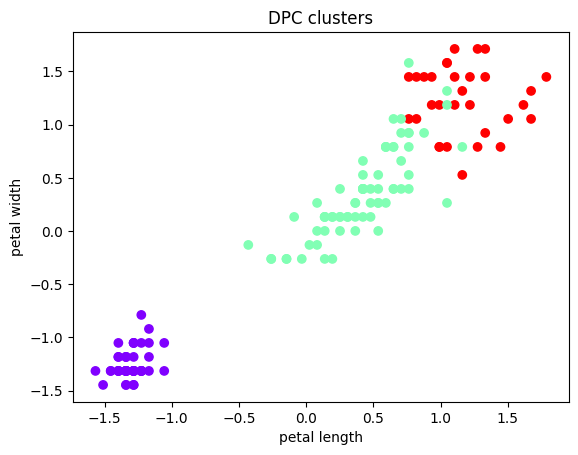

In [ ]:
plot_clusters(X, labels, "DPC clusters")

In [ ]:
ari = adjusted_rand_score(y, labels)

print("DPC ARI =", ari)

DPC ARI = 0.6956362463515929
